In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import plotly.express as px
import pandas as pd
import requests
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [31]:
try:
    df = pd.read_csv('dt_wise_resources_2013_csv_1_1.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'dt_wise_resources_2013_csv_1_1.csv' not found.")
except pd.errors.ParserError:
    print("Error: Unable to parse the CSV file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

,Sl.No,STATE,District,Recharge from Rainfall during Monsoon season(Ham),Recharge From Other Sources during monsoon season(Ham),Recharge from Rainfall during non-monsoon season(Ham),Recharge From Other Sources during non-monsoon season(Ham),Annual Replenishable resources(Ham),Annual Natural Discharge (Ham),Net Annual Ground Water Availability (Ham),Draft due to Irrigation Needs(Ham),Draft due to Domestic & Industrial Water Supply Needs(Ham),Total annual Draft(Ham),Projected demand for Domestic and Industrial uses upto 2025 (Ham),Ground Water Availability for Future Irrigation use (Ham),Stage of Ground Water Develop ment (%)
0,1,ANDHRA PRADESH,Srikakulam,40417.0,38297.0,24646.0,19754.0,123115.0,11733.0,111382.0,38291.0,4504.0,42795.0,17584.0,62902.0,38.0
1,2,ANDHRA PRADESH,Vizianagaram,42539.0,22254.0,28250.0,7492.0,100534.0,8936.0,91598.0,16894.0,918.0,17812.0,6116.0,68723.0,19.0
2,3,ANDHRA PRADESH,Visakhapatnam,73586.0,5905.0,13328.0,5271.0,98090.0,8636.0,89454.0,13442.0,4485.0,17927.0,12541.0,63470.0,20.0
3,4,ANDHRA PRADESH,East Godavari,69958.0,37094.0,38290.0,24618.0,169960.0,16007.0,153953.0,33967.0,9075.0,43042.0,14482.0,106654.0,28.0
4,5,ANDHRA PRADESH,West Godavari,58870.0,42876.0,23364.0,45290.0,170399.0,16033.0,154366.0,59783.0,967.0,60750.0,10080.0,85823.0,39.0


(662, 16)


In [32]:
print("Data Shape:", df.shape)
display(df.info())

Data Shape: (662, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 16 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Sl.No                                                               662 non-null    int64  
 1   STATE                                                               662 non-null    object 
 2   District                                                            662 non-null    object 
 3   Recharge from Rainfall during Monsoon season(Ham)                   651 non-null    float64
 4   Recharge From Other Sources during monsoon season(Ham)              633 non-null    float64
 5   Recharge from Rainfall during non-monsoon season(Ham)               652 non-null    float64
 6   Recharge From Other Sources during non-monsoon season(Ham)          633 non-null    float64


None

In [33]:
display(df.describe())


,Sl.No,Recharge from Rainfall during Monsoon season(Ham),Recharge From Other Sources during monsoon season(Ham),Recharge from Rainfall during non-monsoon season(Ham),Recharge From Other Sources during non-monsoon season(Ham),Annual Replenishable resources(Ham),Annual Natural Discharge (Ham),Net Annual Ground Water Availability (Ham),Draft due to Irrigation Needs(Ham),Draft due to Domestic & Industrial Water Supply Needs(Ham),Total annual Draft(Ham),Projected demand for Domestic and Industrial uses upto 2025 (Ham),Ground Water Availability for Future Irrigation use (Ham),Stage of Ground Water Develop ment (%)
count,662.000000,651.000000,633.000000,652.000000,633.000000,661.000000,660.000000,661.000000,652.000000,661.000000,661.000000,652.000000,651.000000,661.000000
mean,331.500000,39921.859810,11389.723580,6219.474203,11740.867627,67605.056929,5391.082353,62222.133120,35015.219297,3747.013953,38285.469307,4849.539989,24920.340089,61.489589
std,191.247222,34801.442148,17282.387666,9371.231039,13611.389341,56677.140675,5171.067140,52131.162805,43723.156647,3688.796994,45154.838914,4974.559913,38658.101344,50.858506
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-194037.000000,0.000000
25%,166.250000,14554.000000,868.680000,76.192500,1616.390000,26620.679000,2036.550000,23832.000000,3811.467500,1413.580000,5844.680000,1592.000000,4101.010000,27.000000
50%,331.500000,32150.120000,5111.000000,3531.245000,7327.090000,54930.000000,3966.580000,50683.950000,21710.000000,2860.690000,24610.280000,3499.620000,18984.050000,54.000000
75%,496.750000,54485.115000,14245.020000,7410.390000,16751.000000,94394.640000,7022.082500,87889.250000,49973.750000,5019.260000,54693.810000,6545.000000,38198.540000,83.000000
max,662.000000,241691.730000,128976.000000,70126.000000,85132.000000,363854.660000,34991.160000,328863.500000,362759.000000,34160.250000,366426.000000,46578.000000,264315.120000,411.000000


In [34]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print("\nMissing Values:\n", missing_values)



Missing Values:
 Sl.No                                                                  0
STATE                                                                  0
District                                                               0
Recharge from Rainfall during Monsoon season(Ham)                     11
Recharge From Other Sources during monsoon season(Ham)                29
Recharge from Rainfall during non-monsoon season(Ham)                 10
Recharge From Other Sources during non-monsoon season(Ham)            29
Annual Replenishable resources(Ham)                                    1
Annual Natural Discharge (Ham)                                         2
Net Annual Ground Water Availability  (Ham)                            1
Draft due to Irrigation Needs(Ham)                                    10
Draft due to Domestic & Industrial Water Supply Needs(Ham)             1
Total annual Draft(Ham)                                                1
Projected demand for Domestic and

In [35]:
print("\nMissing Value Percentage:\n", missing_percentage)


Missing Value Percentage:
 Sl.No                                                                 0.000000
STATE                                                                 0.000000
District                                                              0.000000
Recharge from Rainfall during Monsoon season(Ham)                     1.661631
Recharge From Other Sources during monsoon season(Ham)                4.380665
Recharge from Rainfall during non-monsoon season(Ham)                 1.510574
Recharge From Other Sources during non-monsoon season(Ham)            4.380665
Annual Replenishable resources(Ham)                                   0.151057
Annual Natural Discharge (Ham)                                        0.302115
Net Annual Ground Water Availability  (Ham)                           0.151057
Draft due to Irrigation Needs(Ham)                                    1.510574
Draft due to Domestic & Industrial Water Supply Needs(Ham)            0.151057
Total annual Draft(Ham) 

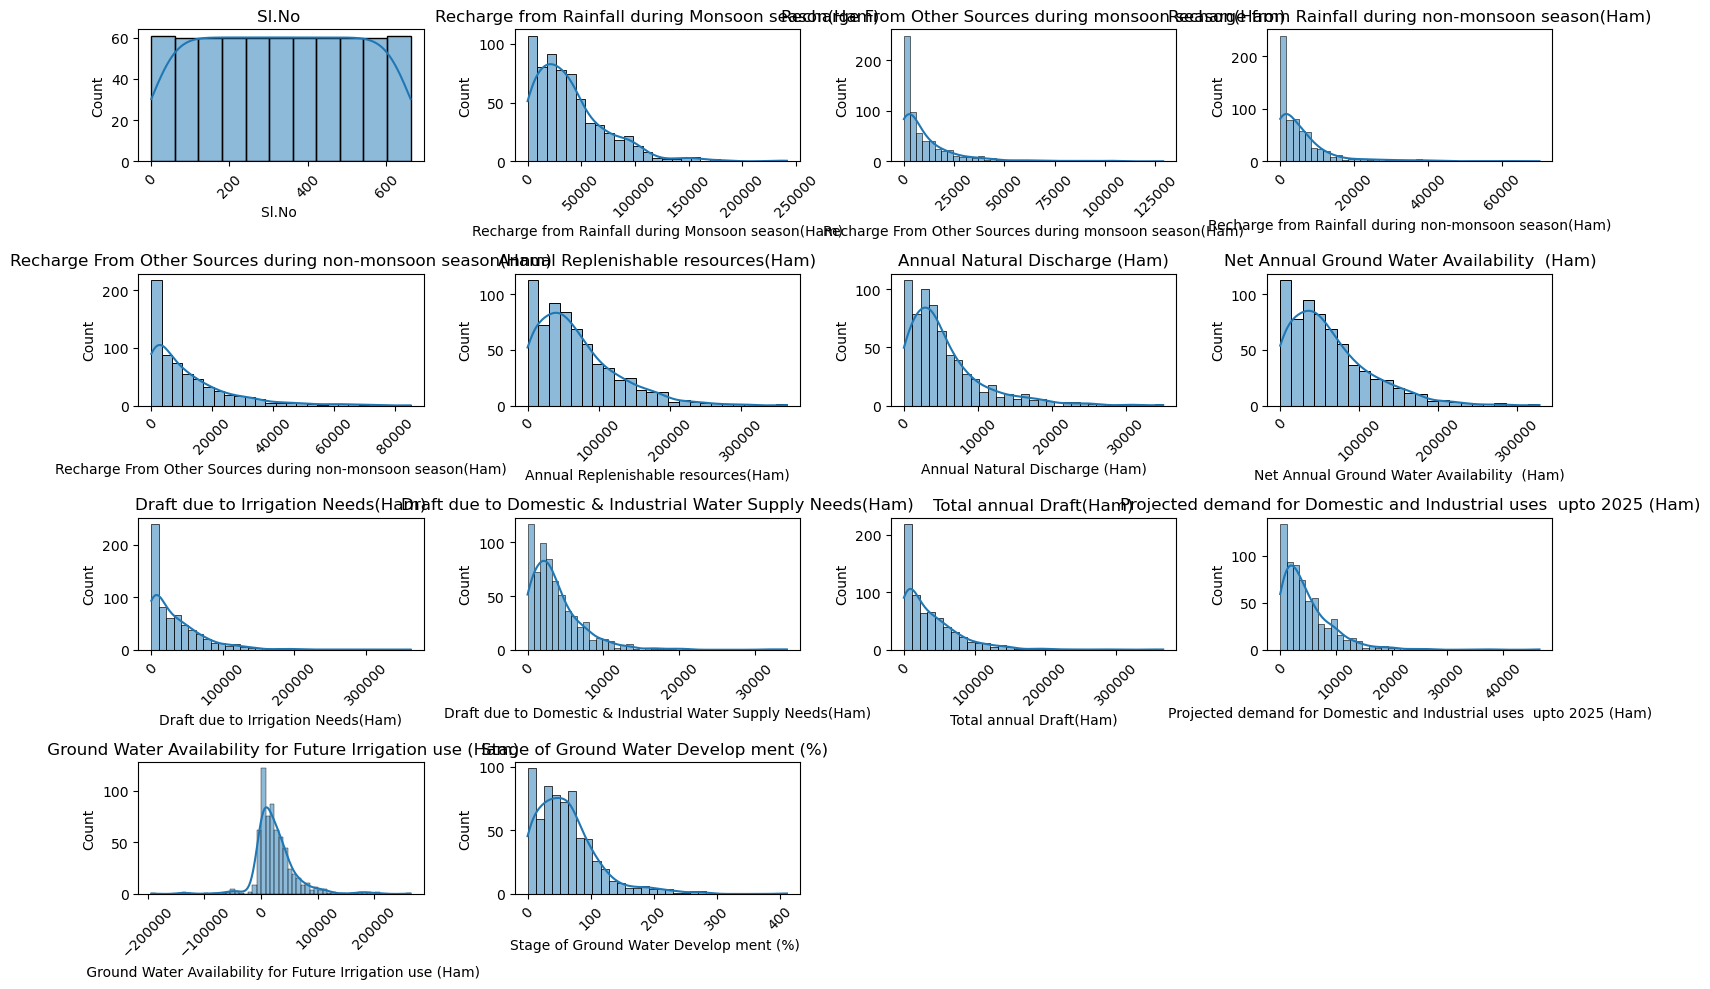

In [36]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)
    if df[col].nunique() < 10:
        sns.countplot(x=df[col])
    else:
        sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
print("\nUnique Value Counts:\n", df.nunique())


Unique Value Counts:
 Sl.No                                                                 662
STATE                                                                  35
District                                                              658
Recharge from Rainfall during Monsoon season(Ham)                     648
Recharge From Other Sources during monsoon season(Ham)                603
Recharge from Rainfall during non-monsoon season(Ham)                 514
Recharge From Other Sources during non-monsoon season(Ham)            618
Annual Replenishable resources(Ham)                                   657
Annual Natural Discharge (Ham)                                        655
Net Annual Ground Water Availability  (Ham)                           657
Draft due to Irrigation Needs(Ham)                                    598
Draft due to Domestic & Industrial Water Supply Needs(Ham)            646
Total annual Draft(Ham)                                               652
Projected deman

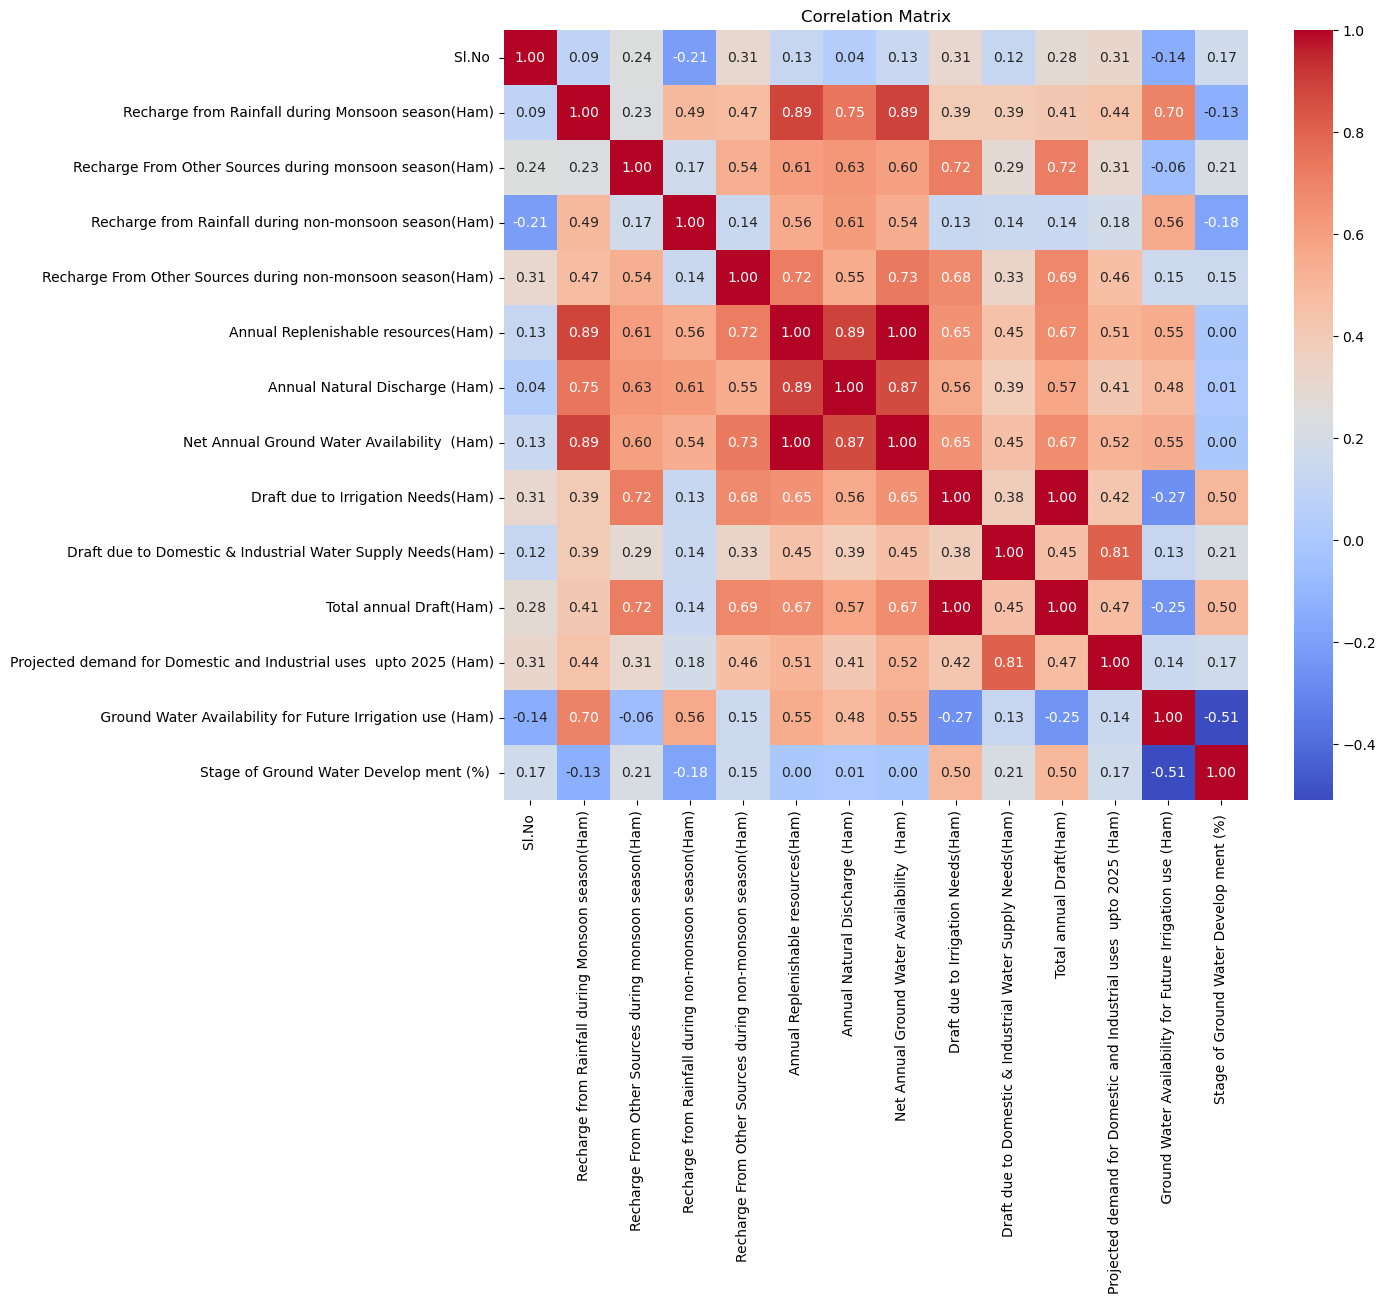

In [38]:
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [39]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [40]:
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    df[col] = np.clip(df[col], df[col].quantile(0.05), df[col].quantile(0.95))


In [41]:
numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    df[col] = np.clip(df[col], df[col].quantile(0.05), df[col].quantile(0.95))


In [42]:
for col in df.columns:
    if col != 'STATE' and col != 'District' and pd.api.types.is_numeric_dtype(df[col]) == False:
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].fillna(df[col].median())
        except:
            pass

In [43]:
df.drop_duplicates(inplace=True)

In [44]:
print("Number of missing values after imputation:", df.isnull().sum().sum())

Number of missing values after imputation: 0


In [45]:

print("Number of duplicates after removal:", df.duplicated().sum())
print("Data types after conversion:")
display(df.dtypes)

Number of duplicates after removal: 0
Data types after conversion:


Sl.No                                                                 float64
STATE                                                                  object
District                                                               object
Recharge from Rainfall during Monsoon season(Ham)                     float64
Recharge From Other Sources during monsoon season(Ham)                float64
Recharge from Rainfall during non-monsoon season(Ham)                 float64
Recharge From Other Sources during non-monsoon season(Ham)            float64
Annual Replenishable resources(Ham)                                   float64
Annual Natural Discharge (Ham)                                        float64
Net Annual Ground Water Availability  (Ham)                           float64
Draft due to Irrigation Needs(Ham)                                    float64
Draft due to Domestic & Industrial Water Supply Needs(Ham)            float64
Total annual Draft(Ham)                                         

In [46]:
categorical_cols = ['STATE', 'District']
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()


In [47]:
for col in categorical_cols:
    if col in numerical_cols:
        numerical_cols.remove(col)

In [48]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop='first')


In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


In [50]:
df_processed = preprocessor.fit_transform(df)

In [51]:
feature_names = numerical_cols.copy()
feature_names.extend(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols))



In [52]:
df_processed = pd.DataFrame(df_processed, columns=feature_names)

display(df_processed.head())

,Sl.No,Recharge from Rainfall during Monsoon season(Ham),Recharge From Other Sources during monsoon season(Ham),Recharge from Rainfall during non-monsoon season(Ham),Recharge From Other Sources during non-monsoon season(Ham),Annual Replenishable resources(Ham),Annual Natural Discharge (Ham),Net Annual Ground Water Availability (Ham),Draft due to Irrigation Needs(Ham),Draft due to Domestic & Industrial Water Supply Needs(Ham),...,District_West Khasi Hills,District_West Siang,District_West Singhbhum,District_West Tripura,District_Wokha,District_Yadgir,District_Yamunanagar,District_Yanam,District_Yeotmal,District_Zunheboto
0,-1.579161,0.080183,2.392048,2.898157,0.817207,1.146038,1.505181,1.097993,0.185002,0.343736,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.579161,0.152849,1.045373,2.939261,-0.301883,0.697389,0.865878,0.672780,-0.458177,-0.914309,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.579161,1.216023,-0.326987,1.185594,-0.504582,0.648831,0.797308,0.626700,-0.561942,0.337070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-1.579161,1.091786,2.291066,2.939261,1.261119,2.076775,2.482077,2.012962,0.055026,1.947340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.579161,0.712088,2.773380,2.704173,2.478364,2.085497,2.488020,2.021839,0.831038,-0.897119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
from sklearn.model_selection import train_test_split

In [54]:
X = df_processed.drop(' Ground Water Availability for Future Irrigation use (Ham)', axis=1)
y = df_processed[' Ground Water Availability for Future Irrigation use (Ham)']


In [55]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)


In [56]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [57]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (463, 704)
y_train shape: (463,)
X_val shape: (99, 704)
y_val shape: (99,)
X_test shape: (100, 704)
y_test shape: (100,)


In [59]:
rf_model = RandomForestRegressor()
gb_model = GradientBoostingRegressor()
lr_model = LinearRegression()


In [60]:
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

LinearRegression()

In [62]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [69]:
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1],
    'max_depth': [3, 5, 7]
}

param_grid_lr = {
    'fit_intercept': [True, False],
    'positive': [True, False] # Use 'positive' instead of 'normalize'
}

In [70]:
scorer = make_scorer(mean_squared_error, greater_is_better=False)


In [71]:
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, scoring=scorer, cv=5)
grid_search_gb = GridSearchCV(estimator=gb_model, param_grid=param_grid_gb, scoring=scorer, cv=5)
grid_search_lr = GridSearchCV(estimator=lr_model, param_grid=param_grid_lr, scoring=scorer, cv=5)



In [72]:
grid_search_rf.fit(X_val, y_val)
grid_search_gb.fit(X_val, y_val)
grid_search_lr.fit(X_val, y_val)


GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring=make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'))

In [73]:
best_rf_model = grid_search_rf.best_estimator_
best_gb_model = grid_search_gb.best_estimator_
best_lr_model = grid_search_lr.best_estimator_

In [74]:
print("Best Random Forest Model:", best_rf_model)
print("Best Gradient Boosting Model:", best_gb_model)
print("Best Linear Regression Model:", best_lr_model)

Best Random Forest Model: RandomForestRegressor(max_depth=20, min_samples_split=5)
Best Gradient Boosting Model: GradientBoostingRegressor(n_estimators=200)
Best Linear Regression Model: LinearRegression(fit_intercept=False)


In [76]:
y_pred_rf = best_rf_model.predict(X_test)
y_pred_gb = best_gb_model.predict(X_test)
y_pred_lr = best_lr_model.predict(X_test)

In [77]:
evaluation_metrics = {}

evaluation_metrics['Random Forest'] = {
    'R-squared': r2_score(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf),
    'MAE': mean_absolute_error(y_test, y_pred_rf)
}

evaluation_metrics['Gradient Boosting'] = {
    'R-squared': r2_score(y_test, y_pred_gb),
    'MSE': mean_squared_error(y_test, y_pred_gb),
    'MAE': mean_absolute_error(y_test, y_pred_gb)
}

evaluation_metrics['Linear Regression'] = {
    'R-squared': r2_score(y_test, y_pred_lr),
    'MSE': mean_squared_error(y_test, y_pred_lr),
    'MAE': mean_absolute_error(y_test, y_pred_lr)
}


In [78]:
for model, metrics in evaluation_metrics.items():
    print(f"Evaluation metrics for {model}:")
    for metric, value in metrics.items():
        print(f"{metric}: {value}")
    print("-" * 20)

Evaluation metrics for Random Forest:
R-squared: 0.9015793298817925
MSE: 0.10390749932210838
MAE: 0.21852975746409517
--------------------
Evaluation metrics for Gradient Boosting:
R-squared: 0.8892440109882918
MSE: 0.1169304968085613
MAE: 0.2264940791641329
--------------------
Evaluation metrics for Linear Regression:
R-squared: 0.9315354890785839
MSE: 0.07228132173466548
MAE: 0.17908448169019453
--------------------


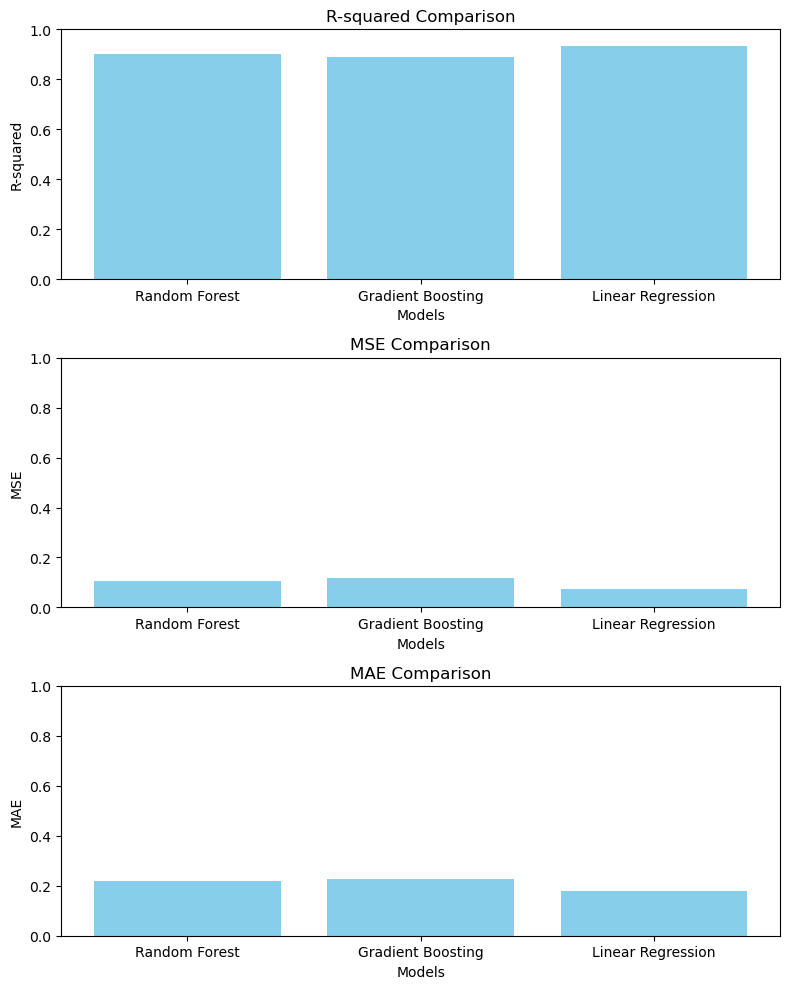

In [79]:
# Prepare the data for plotting
models = list(evaluation_metrics.keys())
metrics = list(evaluation_metrics[models[0]].keys())  # Assuming all models have the same metrics
metric_values = {metric: [evaluation_metrics[model][metric] for model in models] for metric in metrics}

# Create the plots for each metric
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, 10))

for i, metric in enumerate(metrics):
    axes[i].bar(models, metric_values[metric], color='skyblue')
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlabel('Models')
    axes[i].set_ylabel(f'{metric}')
    axes[i].set_ylim([0, 1])  # Assuming metrics are between 0 and 1

plt.tight_layout()
plt.show()

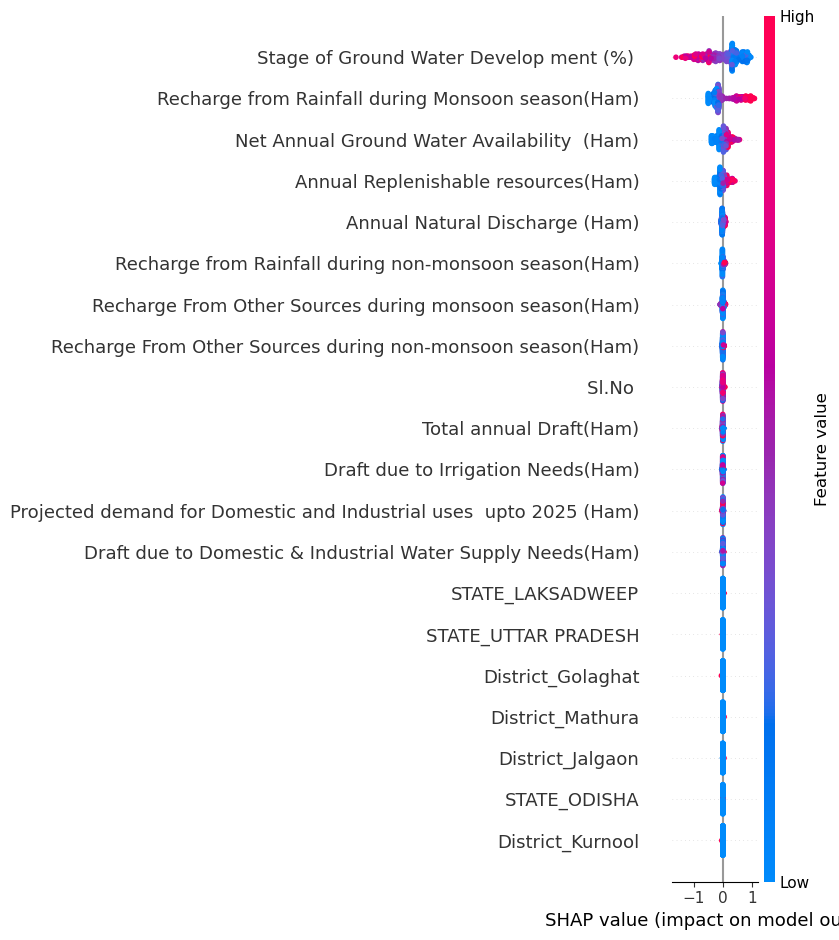

In [80]:
import shap
from sklearn.ensemble import RandomForestRegressor

# Train a RandomForestRegressor for XAI
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# SHAP Values
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_train)

# Visualize SHAP summary plot
shap.summary_plot(shap_values, X_train)


In [81]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Reshape data for LSTM (samples, time steps, features)
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val_lstm = X_val.values.reshape((X_val.shape[0], 1, X_val.shape[1]))

# Scale features
scaler = MinMaxScaler()
X_train_lstm = scaler.fit_transform(X_train_lstm.reshape(-1, X_train_lstm.shape[2])).reshape(X_train_lstm.shape)
X_val_lstm = scaler.transform(X_val_lstm.reshape(-1, X_val_lstm.shape[2])).reshape(X_val_lstm.shape)

# Define LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(units=1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Fit the model
model_lstm.fit(X_train_lstm, y_train, epochs=10, batch_size=32)

# Evaluate the model on validation data
lstm_pred = model_lstm.predict(X_val_lstm)
lstm_mse = mean_squared_error(y_val, lstm_pred)
print(f"LSTM Model MSE: {lstm_mse}")


Epoch 1/10


C:\Users\0871\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9721
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9951 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7957 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7239 
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4023 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2345 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1448 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1158 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1093 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0857 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
LSTM Model MSE: 0.14047712791849354


In [84]:
print("R-squared:",r2_score(y_val, lstm_pred))
print("MSE:", mean_squared_error(y_val, lstm_pred))
print("MAE:",mean_absolute_error(y_val, lstm_pred))

R-squared: 0.8666082732681395
MSE: 0.14047712791849354
MAE: 0.2973868063126006


In [86]:
import shap
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define base models
base_learners = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
]

# Meta-model (a regressor that combines base models)
meta_model = Ridge(alpha=1.0)

# Stacking Regressor
stacking_model = StackingRegressor(estimators=base_learners, final_estimator=meta_model)

# Train the stacking model
stacking_model.fit(X_train, y_train)

# Evaluate the model
stacking_pred = stacking_model.predict(X_val)
stacking_mse = mean_squared_error(y_val, stacking_pred)
print(f"Stacking Regressor MSE: {stacking_mse}")



Stacking Regressor MSE: 0.03663004545959528


In [87]:
print("R-squared:",r2_score(y_val, stacking_pred))
print("MSE:", mean_squared_error(y_val, stacking_pred))
print("MAE:",mean_absolute_error(y_val, stacking_pred))

R-squared: 0.9652175048954805
MSE: 0.03663004545959528
MAE: 0.12290329124810132


Explaining rf model with SHAP...


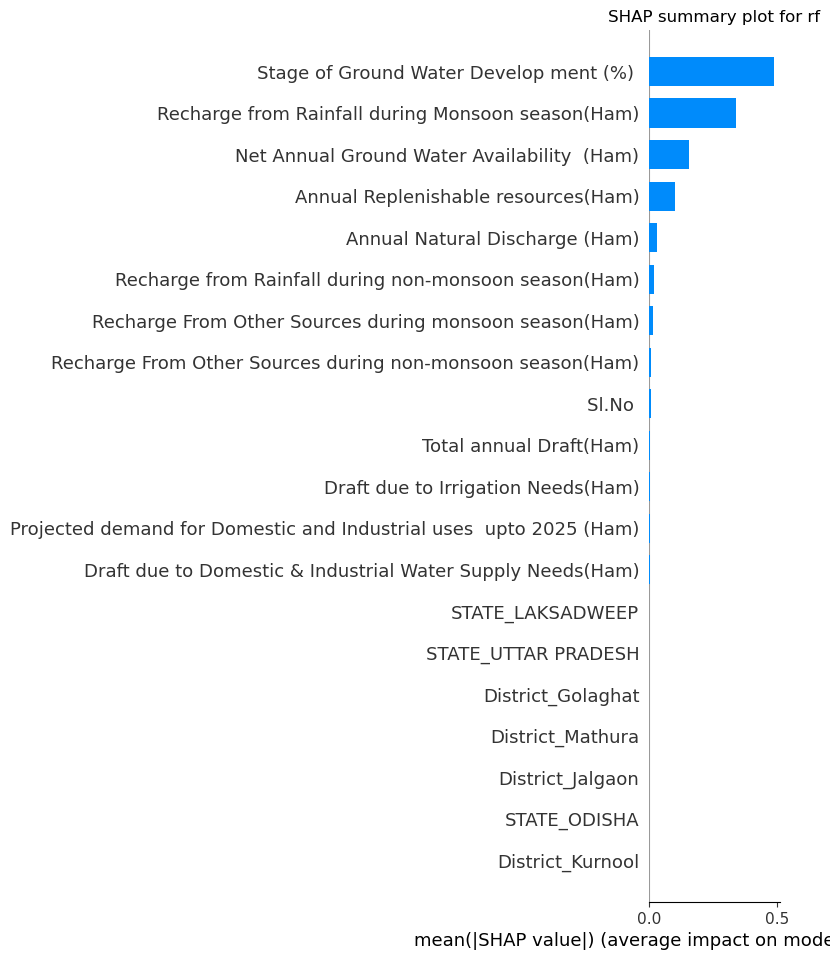

Explaining gb model with SHAP...


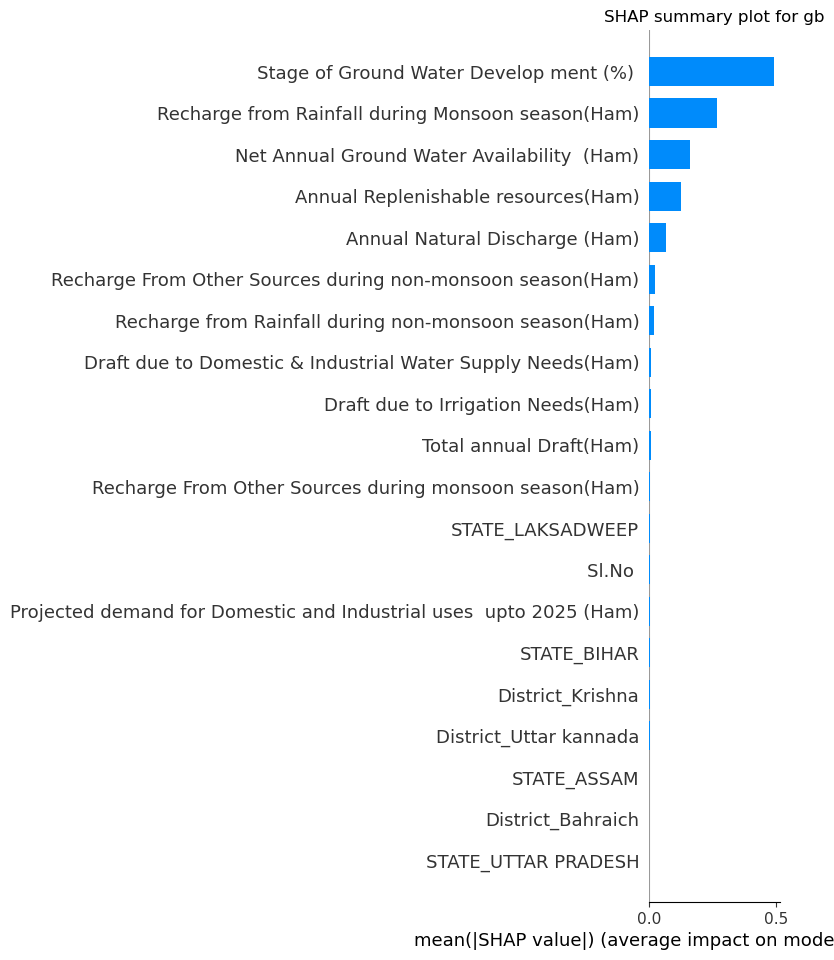

Explaining lr model with SHAP...


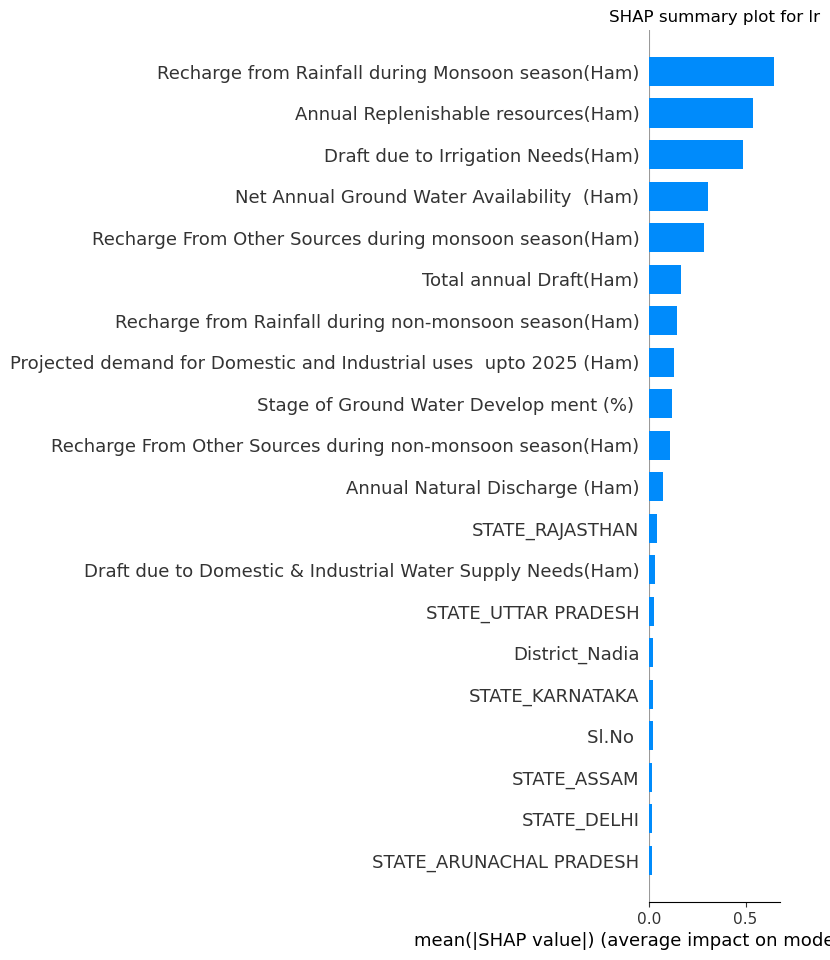

Explaining Meta-model (Ridge) with SHAP...


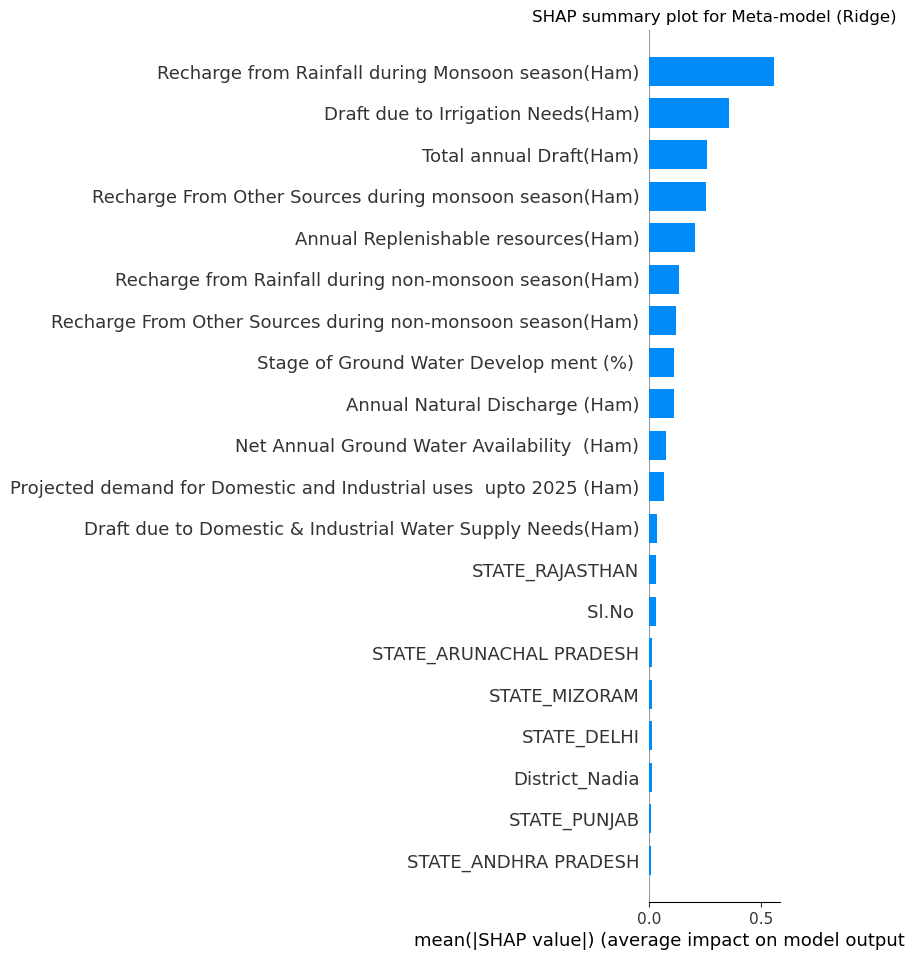

In [93]:
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import StackingRegressor

# Define the base models
base_learners = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
]

# Define the meta-model (Ridge)
meta_model = Ridge(alpha=1.0)

# Create and train the Stacking Regressor
stacking_model = StackingRegressor(estimators=base_learners, final_estimator=meta_model)
stacking_model.fit(X_train, y_train)

# Explaining the base models (Tree-based models like RandomForest and GradientBoosting)
for name, model in base_learners:
    print(f"Explaining {name} model with SHAP...")

    # Train the model before explaining with SHAP
    model.fit(X_train, y_train)

    # Use TreeExplainer for tree-based models
    if isinstance(model, RandomForestRegressor) or isinstance(model, GradientBoostingRegressor):
        explainer = shap.TreeExplainer(model)
    else:
        explainer = shap.Explainer(model, X_train)  # Default explainer for other models
    
    shap_values = explainer.shap_values(X_train)  # Compute SHAP values for training data
    
    # Plot SHAP summary plot for each base model
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
    plt.title(f"SHAP summary plot for {name}")
    plt.show()

# Finally, explain the meta-model (Ridge in this case)
print("Explaining Meta-model (Ridge) with SHAP...")

# Train the meta-model
meta_model.fit(X_train, y_train)

# Use LinearExplainer for the Ridge model
meta_explainer = shap.LinearExplainer(meta_model, X_train)
meta_shap_values = meta_explainer.shap_values(X_train)

# Plot SHAP summary plot for Meta-model (Ridge)
shap.summary_plot(meta_shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP summary plot for Meta-model (Ridge)")
plt.show()
